##**Project:** Student Dropout Prediction using Logistic Regression


**Manahil Ahmad**

# Student Dropout Prediction
### Phase 1: Problem Understanding


**Dataset Link:** https://www.kaggle.com/datasets/meharshanali/student-dropout-prediction-dataset

## 1. Problem Statement

Student dropout is a major challenge for educational institutions, it affects student outcomes, institutional performance, and wastes resources spent on students who eventually leave mid-program.

Early identification allows institutions to intervene before a student actually withdraws through academic support, financial aid, or counseling.

Goal: Build a binary classification model (Logistic Regression) that predicts whether a student is at risk of dropping out, using their academic, demographic, socioeconomic, and enrollment-related information.

## 2. Target Variable

Variable: Dropout

Type: Binary(0/1)

Meaning: 0 = Did not drop out, 1 = Dropped out


Note: this target is imbalanced (~76% class 0, ~24% class 1). This will matter later when choosing evaluation metrics — accuracy alone will be misleading, so precision, recall, F1-score, and ROC-AUC will be used in Phase 6.

##3. Input Features
| Category                   | Features                                                                                  |
| -------------------------- | ----------------------------------------------------------------------------------------- |
Demographic           | Age, Gender, Parental_Education                                                    |
| Socioeconomic| Family_Income, Internet_Acces, Part_Time_Job, Scholarship, Travel_Time_Minutes
|Academic | GPA, Semester_GPA`, CGPA, Attendance_Rate, Assignment_Delay_Days|
|Behavioral / Wellbeing | Study_Hours_per_Day, Stress_Index  |
| Enrollment| Semester, Department                                                                 |
|Identifier| student_ID it will not be used as a model feature


## 4. Real-World Application

A university could use this system as an early-warning tool to identify currently enrolled students who may be at higher risk of dropping out. Students flagged as high-risk could then be referred to academic advisors, counselors, or financial-aid staff for appropriate support. This would allow the institution to take proactive action instead of waiting until a student has already withdrawn.

# Project Phase 2 : Dataset Collection & Exploration

## 2.1 Dataset Overview

The student dropout dataset contains academic, demographic, socioeconomic, behavioral, and enrollment-related information about students.

The purpose of this phase is to explore the dataset structure, understand the available features, identify the target variable, and examine the distribution of dropout cases before model development.

**Import and Load Dataset**

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import pandas as pd

# Load the dataset
path = 'student_dropout_dataset_v3.csv'
df = pd.read_csv("/content/drive/MyDrive/student_dropout_dataset_v3.csv")

print("First 5 Rows:")
df.head(5)

First 5 Rows:


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0


**Data Types**

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA           10000 non-null  float64
 14  CGPA                   10000 non-null  float64
 15  Sem

**Dataset Shape**

In [36]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 10000
Number of Columns: 19


**Dataset Columns**

In [37]:
print("Dataset Columns:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Dataset Columns:

1. Student_ID
2. Age
3. Gender
4. Family_Income
5. Internet_Access
6. Study_Hours_per_Day
7. Attendance_Rate
8. Assignment_Delay_Days
9. Travel_Time_Minutes
10. Part_Time_Job
11. Scholarship
12. Stress_Index
13. GPA
14. Semester_GPA
15. CGPA
16. Semester
17. Department
18. Parental_Education
19. Dropout


**Numerical and Categorical Features**

In [38]:
print("Numerical Features:")
print(df.select_dtypes(include='number').columns.tolist())

print("\nCategorical Features:")
print(df.select_dtypes(include='object').columns.tolist())

Numerical Features:
['Student_ID', 'Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Dropout']

Categorical Features:
['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education']


**Target Distribution**

In [39]:
print("Dropout Distribution:")
print(df['Dropout'].value_counts())

print("\nDropout Percentage:")
print((df['Dropout'].value_counts(normalize=True) * 100).round(2))

Dropout Distribution:
Dropout
0    7646
1    2354
Name: count, dtype: int64

Dropout Percentage:
Dropout
0    76.46
1    23.54
Name: proportion, dtype: float64


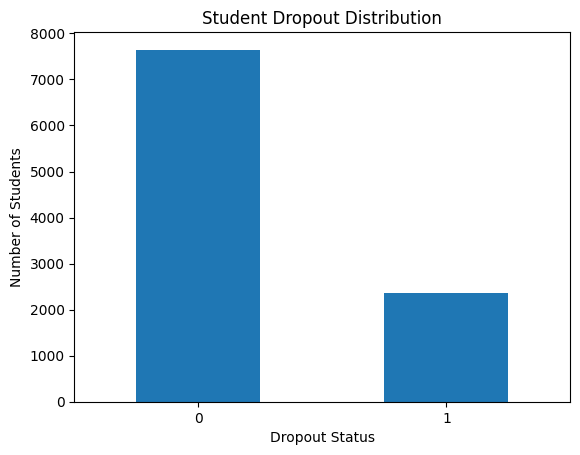

In [40]:
import matplotlib.pyplot as plt

df['Dropout'].value_counts().plot(kind='bar')

plt.title('Student Dropout Distribution')
plt.xlabel('Dropout Status')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.show()

# Project Phase 3 : Data Cleaning & Preprocessing

## 3.1 Data Cleaning and Preprocessing

**Check Missing Values**

In [41]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Student_ID                 0
Age                        0
Gender                     0
Family_Income            500
Internet_Access            0
Study_Hours_per_Day      500
Attendance_Rate            0
Assignment_Delay_Days      0
Travel_Time_Minutes        0
Part_Time_Job              0
Scholarship                0
Stress_Index             500
GPA                        0
Semester_GPA               0
CGPA                       0
Semester                   0
Department                 0
Parental_Education       511
Dropout                    0
dtype: int64


**Missing-Value Summary**

In [42]:
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().mean() * 100).round(2)
})

missing_summary

,Missing Values,Missing Percentage
Student_ID,0,0.00
Age,0,0.00
Gender,0,0.00
Family_Income,500,5.00
Internet_Access,0,0.00
Study_Hours_per_Day,500,5.00
Attendance_Rate,0,0.00
Assignment_Delay_Days,0,0.00
Travel_Time_Minutes,0,0.00
Part_Time_Job,0,0.00


**Handle the missing values**

In [43]:
# Create a copy for preprocessing
df_clean = df.copy()

# Identify numerical and categorical columns
numeric_columns = df_clean.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df_clean.select_dtypes(include=['object']).columns

# Fill numerical missing values with the median
for column in numeric_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

# Fill categorical missing values with the mode
for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])

print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
Student_ID               0
Age                      0
Gender                   0
Family_Income            0
Internet_Access          0
Study_Hours_per_Day      0
Attendance_Rate          0
Assignment_Delay_Days    0
Travel_Time_Minutes      0
Part_Time_Job            0
Scholarship              0
Stress_Index             0
GPA                      0
Semester_GPA             0
CGPA                     0
Semester                 0
Department               0
Parental_Education       0
Dropout                  0
dtype: int64


**Cleaning the Dataset**
Remove student_ID

In [44]:
# Remove identifier column
df_clean = df_clean.drop(columns=['Student_ID'])

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (10000, 19)
Cleaned shape: (10000, 18)


**Check Duplicates**

In [45]:
print("Number of duplicate rows:", df_clean.duplicated().sum())

Number of duplicate rows: 0


**Encoding Categorical Variables**

In [46]:
categorical_columns = df_clean.select_dtypes(include=['object']).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship', 'Semester', 'Department', 'Parental_Education']


In [47]:
df_encoded = pd.get_dummies(
    df_clean,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Shape after encoding:", df_encoded.shape)

Shape after encoding: (10000, 25)


In [48]:
df_encoded.head()

,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,...,Semester_Year 2,Semester_Year 3,Semester_Year 4,Department_Business,Department_CS,Department_Engineering,Department_Science,Parental_Education_High School,Parental_Education_Master,Parental_Education_PhD
0,22.1,25000.0,3.36,86.1,2,20.4,5.5,0.96,0.90,0.90,...,0,0,0,0,0,0,0,1,0,0
1,20.7,25000.0,4.30,68.0,2,44.0,6.8,1.28,1.20,1.19,...,0,1,0,0,0,1,0,0,0,0
2,22.4,40183.0,4.40,70.9,0,48.9,5.5,1.68,1.32,1.32,...,0,0,0,0,0,0,0,0,1,0
3,24.4,29740.5,4.00,82.2,2,38.6,5.5,1.78,1.77,1.77,...,0,0,0,0,1,0,0,1,0,0
4,20.5,25319.0,4.19,75.7,1,23.0,7.0,1.48,0.91,0.87,...,0,0,1,1,0,0,0,0,0,0



**Separate Features and Target**

In [49]:
X = df_encoded.drop(columns=['Dropout'])
y = df_encoded['Dropout']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (10000, 24)
Target (y) shape: (10000,)


**Final Dataset**

In [50]:
print("Final feature dataset:")
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFinal feature columns:")
print(X.columns.tolist())

Final feature dataset:
X shape: (10000, 24)
y shape: (10000,)

Final feature columns:
['Age', 'Family_Income', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA', 'Gender_Male', 'Internet_Access_Yes', 'Part_Time_Job_Yes', 'Scholarship_Yes', 'Semester_Year 2', 'Semester_Year 3', 'Semester_Year 4', 'Department_Business', 'Department_CS', 'Department_Engineering', 'Department_Science', 'Parental_Education_High School', 'Parental_Education_Master', 'Parental_Education_PhD']


Phase 4 : Exploratory Data Analysis

**Dropout Distribution**

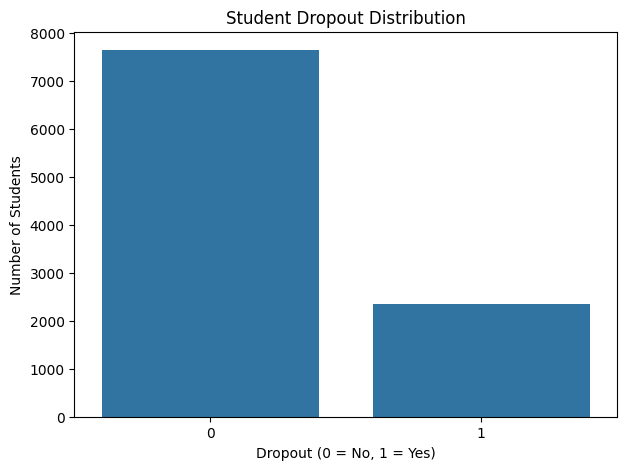

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dropout distribution
dropout_counts = df_clean['Dropout'].value_counts().sort_index()

plt.figure(figsize=(7, 5))
sns.barplot(x=dropout_counts.index, y=dropout_counts.values)

plt.title('Student Dropout Distribution')
plt.xlabel('Dropout (0 = No, 1 = Yes)')
plt.ylabel('Number of Students')
plt.show()

**Academic Performance vs Dropout**

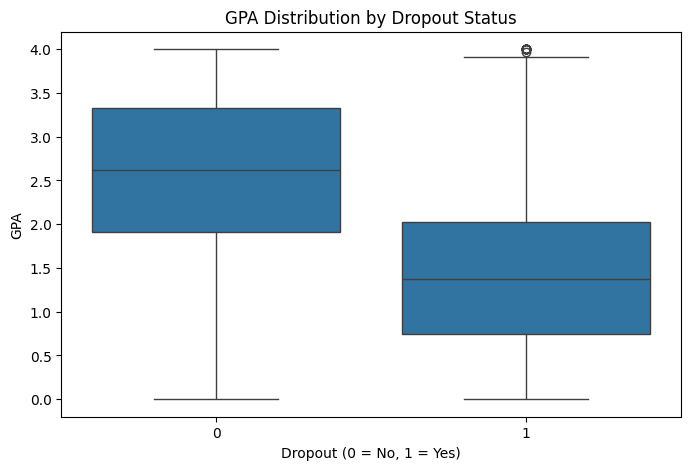

In [52]:
#GPA by dropout status
plt.figure(figsize=(8, 5))
sns.boxplot(x='Dropout', y='GPA', data=df_clean)

plt.title('GPA Distribution by Dropout Status')
plt.xlabel('Dropout (0 = No, 1 = Yes)')
plt.ylabel('GPA')
plt.show()

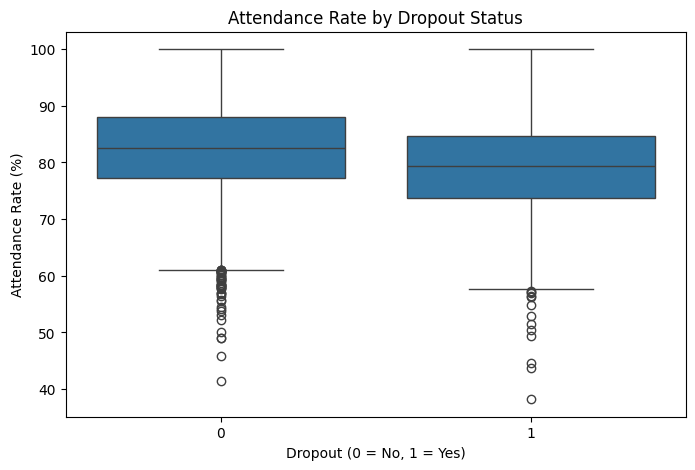

In [53]:
#Attendance vs Dropout
plt.figure(figsize=(8, 5))
sns.boxplot(x='Dropout', y='Attendance_Rate', data=df_clean)

plt.title('Attendance Rate by Dropout Status')
plt.xlabel('Dropout (0 = No, 1 = Yes)')
plt.ylabel('Attendance Rate (%)')
plt.show()

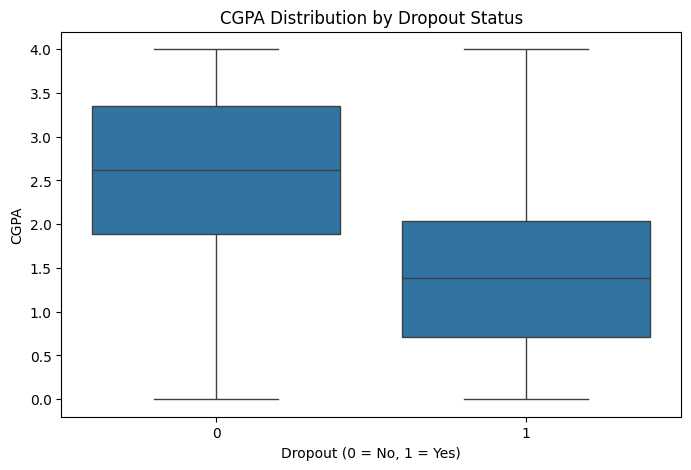

In [54]:
#CGPA vs Dropout
plt.figure(figsize=(8, 5))
sns.boxplot(x='Dropout', y='CGPA', data=df_clean)

plt.title('CGPA Distribution by Dropout Status')
plt.xlabel('Dropout (0 = No, 1 = Yes)')
plt.ylabel('CGPA')
plt.show()

**Feature Relationships**

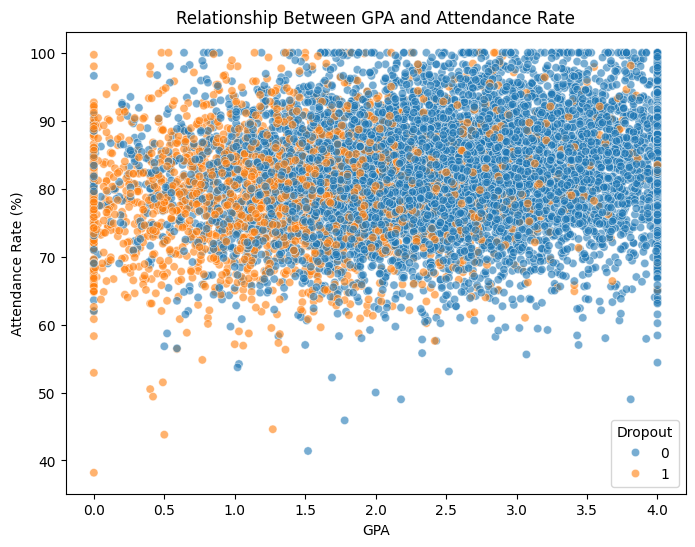

In [55]:
#GPA vs Attendance
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clean,
    x='GPA',
    y='Attendance_Rate',
    hue='Dropout',
    alpha=0.6
)

plt.title('Relationship Between GPA and Attendance Rate')
plt.xlabel('GPA')
plt.ylabel('Attendance Rate (%)')
plt.show()

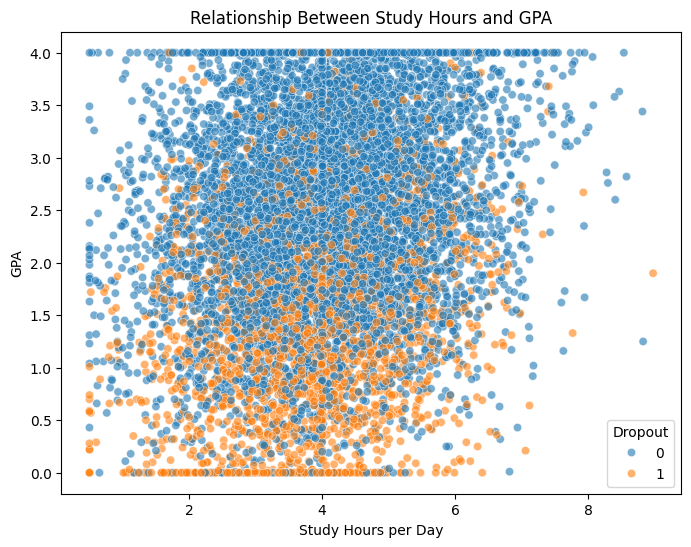

In [56]:
#Study Hours vs GPA
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_clean,
    x='Study_Hours_per_Day',
    y='GPA',
    hue='Dropout',
    alpha=0.6
)

plt.title('Relationship Between Study Hours and GPA')
plt.xlabel('Study Hours per Day')
plt.ylabel('GPA')
plt.show()

**Numerical Feature Correlation**

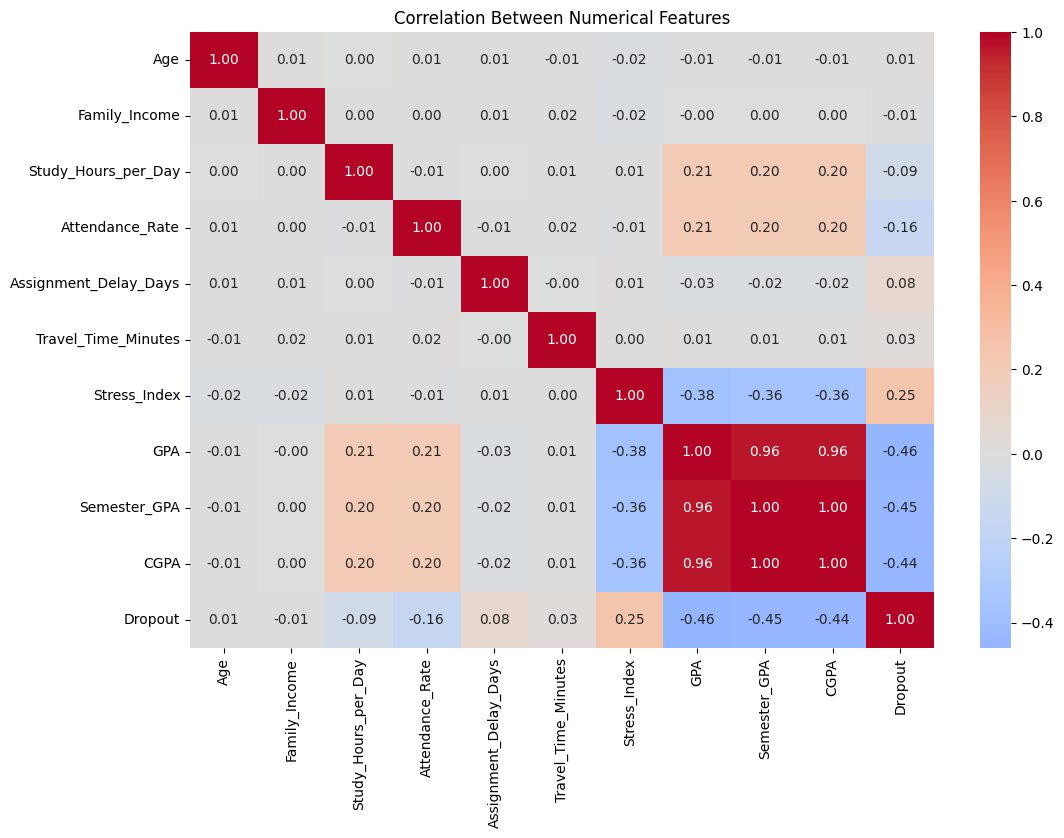

In [57]:
# Correlation Heatmap
# Select numerical features
numeric_df = df_clean.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Between Numerical Features')
plt.show()

**Compare Important Features by Dropout**

In [58]:
# Compare important numerical features by dropout status

comparison = df_clean.groupby('Dropout')[
    ['GPA',
     'Semester_GPA',
     'CGPA',
     'Attendance_Rate',
     'Study_Hours_per_Day',
     'Stress_Index']
].mean()

comparison.round(2)

,GPA,Semester_GPA,CGPA,Attendance_Rate,Study_Hours_per_Day,Stress_Index
Dropout,,,,,,
0,2.58,2.57,2.56,82.48,4.07,5.27
1,1.43,1.44,1.44,79.31,3.82,6.28


## Important Observations

Based on the exploratory analysis:

1. The dataset contains both dropout and non-dropout students, with more students in the non-dropout group.

2. Dropout students generally show lower academic performance than non-dropout students, particularly in GPA and Semester GPA.

3. Dropout students have a lower average number of study hours per day compared with non-dropout students.

4. The average Stress Index is higher among dropout students, suggesting that stress may be an important factor associated with dropout outcomes.

5. Academic performance and attendance can be examined together to identify students who may require early academic support.

6. The correlation analysis helps identify relationships between numerical features and can guide the selection of useful variables for the Logistic Regression model.

7. These observations do not prove that a particular factor causes dropout. They only show patterns and relationships present in the dataset.

##Phase 5 — Logistic Regression Model

**Train/Test Split**

In [59]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_encoded.drop(columns=['Dropout'])
y = df_encoded['Dropout']

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (8000, 24)
Testing data shape: (2000, 24)


**Then Train the Model**

In [60]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression(max_iter=1000)

# Train the model
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Make Predictions**

In [61]:
# Predict dropout status for test data
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[0 0 0 0 0 0 0 0 0 0]


**Prediction Probabilities**

In [62]:
# Get prediction probabilities
y_prob = model.predict_proba(X_test)

print("First 10 prediction probabilities:")
print(y_prob[:10])

First 10 prediction probabilities:
[[0.88704417 0.11295583]
 [0.70764051 0.29235949]
 [0.93402262 0.06597738]
 [0.74111865 0.25888135]
 [0.51375231 0.48624769]
 [0.94759039 0.05240961]
 [0.98300268 0.01699732]
 [0.7051296  0.2948704 ]
 [0.70470169 0.29529831]
 [0.61631235 0.38368765]]


In [63]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nFirst 10 Actual Values:")
print(y_test.iloc[:10].values)

print("\nFirst 10 Predictions:")
print(y_pred[:10])

print("\nFirst 10 Prediction Probabilities:")
print(y_prob[:10])

Training samples: 8000
Testing samples: 2000

First 10 Actual Values:
[0 0 0 0 1 0 0 0 0 0]

First 10 Predictions:
[0 0 0 0 0 0 0 0 0 0]

First 10 Prediction Probabilities:
[[0.88704417 0.11295583]
 [0.70764051 0.29235949]
 [0.93402262 0.06597738]
 [0.74111865 0.25888135]
 [0.51375231 0.48624769]
 [0.94759039 0.05240961]
 [0.98300268 0.01699732]
 [0.7051296  0.2948704 ]
 [0.70470169 0.29529831]
 [0.61631235 0.38368765]]


## What I Learned

In this phase, I learned how to split data into training and testing sets and train a Logistic Regression model for binary classification. I also learned how to generate predictions and probability scores for student dropout prediction.

##Phase 6: Model Evaluation

**Generate Predictions**

In [64]:
# Generate predictions on the test data
y_pred = model.predict(X_test)

# Generate probability scores for ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


**Accuracy, Precision, Recall & F1-Score**

In [65]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-Score :", round(f1, 4))

Accuracy : 0.815
Precision: 0.6747
Recall   : 0.414
F1-Score : 0.5132


**Classification Report**

In [66]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      1529
           1       0.67      0.41      0.51       471

    accuracy                           0.81      2000
   macro avg       0.76      0.68      0.70      2000
weighted avg       0.80      0.81      0.80      2000



**Confusion Matrix**

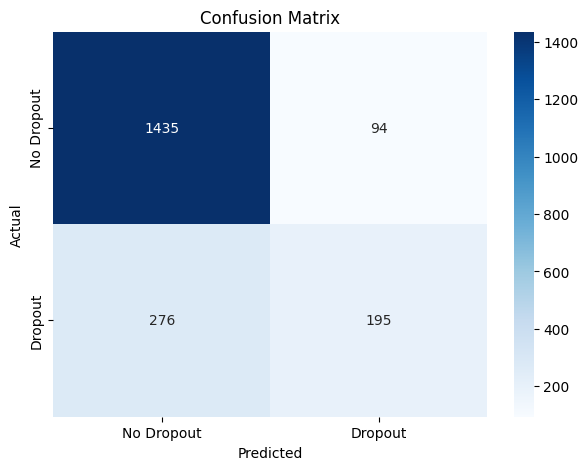

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Dropout', 'Dropout'],
    yticklabels=['No Dropout', 'Dropout']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**ROC-AUC**

In [68]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.8185


In [70]:
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.8150
Precision: 0.6747
Recall   : 0.4140
F1-Score : 0.5132
ROC-AUC  : 0.8185


##Project Phase 7 — Student Dropout Prediction

In [71]:
import joblib

# Save the trained model
joblib.dump(model, 'student_dropout_model.pkl')

# Save the feature columns used by the model
joblib.dump(X.columns.tolist(), 'model_features.pkl')

print("Model and feature columns saved successfully!")

Model and feature columns saved successfully!


In [84]:
!pip install gradio -q

In [85]:
import gradio as gr
import pandas as pd

def predict_dropout(
    age,
    gender,
    family_income,
    internet_access,
    study_hours,
    attendance,
    assignment_delay,
    travel_time,
    part_time_job,
    scholarship,
    stress,
    gpa,
    semester_gpa,
    cgpa,
    semester,
    department,
    parental_education
):

    # Create student input
    input_data = pd.DataFrame({
        "Age": [age],
        "Gender": [gender],
        "Family_Income": [family_income],
        "Internet_Access": [internet_access],
        "Study_Hours_per_Day": [study_hours],
        "Attendance_Rate": [attendance],
        "Assignment_Delay_Days": [assignment_delay],
        "Travel_Time_Minutes": [travel_time],
        "Part_Time_Job": [part_time_job],
        "Scholarship": [scholarship],
        "Stress_Index": [stress],
        "GPA": [gpa],
        "Semester_GPA": [semester_gpa],
        "CGPA": [cgpa],
        "Semester": [semester],
        "Department": [department],
        "Parental_Education": [parental_education]
    })

    # Encode categorical variables
    input_encoded = pd.get_dummies(
        input_data,
        drop_first=True,
        dtype=int
    )

    # Match the training features
    input_encoded = input_encoded.reindex(
        columns=X.columns,
        fill_value=0
    )

    # Predict probability
    probability = model.predict_proba(input_encoded)[0][1]

    # Risk category
    if probability < 0.30:
        risk = "Low Risk"
    elif probability < 0.60:
        risk = "Medium Risk"
    else:
        risk = "High Risk"

    # Prediction
    prediction = model.predict(input_encoded)[0]

    if prediction == 1:
        result = "⚠️ Student may be at risk of dropout."
    else:
        result = "✅ Student is predicted as unlikely to drop out."

    return (
        f"{probability * 100:.2f}%",
        risk,
        result
    )


# Create Gradio interface
demo = gr.Interface(
    fn=predict_dropout,
    inputs=[
        gr.Number(label="Age", value=20),
        gr.Dropdown(["Male", "Female"], label="Gender"),
        gr.Number(label="Family Income", value=50000),
        gr.Dropdown(["Yes", "No"], label="Internet Access"),
        gr.Number(label="Study Hours per Day", value=4),
        gr.Number(label="Attendance Rate (%)", value=75),
        gr.Number(label="Assignment Delay Days", value=2),
        gr.Number(label="Travel Time (Minutes)", value=30),
        gr.Dropdown(["Yes", "No"], label="Part-Time Job"),
        gr.Dropdown(["Yes", "No"], label="Scholarship"),
        gr.Number(label="Stress Index", value=5),
        gr.Number(label="GPA", value=2.5),
        gr.Number(label="Semester GPA", value=2.5),
        gr.Number(label="CGPA", value=2.5),
        gr.Number(label="Semester", value=5),
        gr.Dropdown(
            ["Arts", "Engineering", "CS", "Business", "Science"],
            label="Department"
        ),
        gr.Dropdown(
            ["High School", "Bachelor", "Master", "PhD"],
            label="Parental Education"
        )
    ],
    outputs=[
        gr.Textbox(label="Dropout Probability"),
        gr.Textbox(label="Risk Category"),
        gr.Textbox(label="Prediction")
    ],
    title="Student Dropout Risk Prediction",
    description="Enter student information to estimate dropout probability and risk level."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5a378e6bd7caa4dca3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
